<a href="https://colab.research.google.com/github/DiorgenesSilva/PROJETOS-CLAUD-CODE-/blob/main/PTCG_Estrategia_Analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎴 The Pokémon Company — Estratégia para o Desafio de Batalha de IA do PTCG
## Análise exploratória do dataset de cartas e fundamentação de arquétipo de baralho

**Categoria:** Estratégia (relatório de apoio à Categoria Simulação)

---

### Sobre este notebook

Esta competição tem **duas categorias obrigatórias e interligadas**:

1. **Categoria Simulação** — onde o agente de IA joga partidas reais do Pokémon TCG e é avaliado pela taxa de vitórias.
2. **Categoria Estratégia** (este notebook) — onde explicamos e justificamos a lógica por trás da escolha de baralho e da estratégia do agente, com **dados**, não apenas intuição.

A avaliação da Categoria Estratégia segue estes pesos:

| Critério | Peso | O que cobrimos aqui |
|---|---|---|
| Pontuação do modelo | 70% | Depende do agente em si (fora do escopo deste notebook) |
| Pontuação do baralho | 20% | ✅ Justificativa de cartas-chave via análise de dados |
| Pontuação do relatório | 10% | ✅ Gráficos, tabelas e clareza da explicação |

**Objetivo deste notebook:** usar Pandas, Matplotlib e Seaborn para extrair do dataset oficial de cartas (`EN_Card_Data.csv`) evidências quantitativas que sustentem a escolha de um arquétipo de baralho — cobrindo tipo elemental, eficiência de ataque, cobertura de fraquezas e suporte de cartas de Treinador.

> 💡 **Para quem não é da área:** cada bloco de código abaixo vem acompanhado de uma explicação em duas camadas — o que o comando faz tecnicamente, e o que ele significa em termos simples.


## Passo 0 — Preparando o ambiente

Antes de analisar qualquer dado, importamos as bibliotecas que vamos usar.

**Camada técnica:**
- `pandas` → manipulação de tabelas de dados (carregar CSV, filtrar, agrupar).
- `numpy` → operações matemáticas e tratamento de valores ausentes (`NaN`).
- `matplotlib.pyplot` → motor base para desenhar gráficos.
- `seaborn` → camada sobre o matplotlib que deixa gráficos estatísticos mais bonitos e prontos com menos código.

**Camada leiga:**
Pense nessas bibliotecas como ferramentas de uma caixa de trabalho: o Pandas é a planilha eletrônica que organiza os dados das cartas; o NumPy é a calculadora por trás dela; o Matplotlib e o Seaborn são os "marcadores coloridos" que transformam números em gráficos fáceis de entender.


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Define um estilo visual consistente para todos os gráficos do notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## Passo 1 — Carregando e inspecionando o dataset

Vamos carregar o arquivo `EN_Card_Data.csv`, que contém os metadados de todas as 2022 cartas disponíveis no ambiente competitivo (conforme descrito na aba "Dados" da competição).

**Camada técnica:**
- `pd.read_csv()` lê o arquivo CSV e cria um `DataFrame` (a estrutura de tabela do Pandas).
- `.shape` retorna `(linhas, colunas)`.
- `.info()` mostra tipo de dado e quantidade de valores não-nulos por coluna — essencial para identificar onde há dados ausentes antes de qualquer análise.

**Obs:**
É como abrir a planilha de cartas no Excel e checar quantas linhas e colunas ela tem, e quais células estão vazias. Isso evita erros mais adiante: se uma coluna tem muitos valores ausentes, qualquer conclusão tirada dela precisa de cautela.


In [ ]:
df = pd.read_csv('/mnt/user-data/uploads/EN_Card_Data.csv')

print(f"Dimensões do dataset: {df.shape[0]} cartas, {df.shape[1]} colunas\n")
df.info()

Dimensões do dataset: 2022 cartas, 17 colunas

<class 'pandas.DataFrame'>
RangeIndex: 2022 entries, 0 to 2021
Data columns (total 17 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Card ID                                    2022 non-null   int64  
 1   Card Name                                  2022 non-null   str    
 2   Expansion                                  2012 non-null   str    
 3   Collection No.                             2022 non-null   int64  
 4   Stage (Pokémon)/Type (Energy and Trainer)  2022 non-null   str    
 5   Rule                                       353 non-null    str    
 6   Category                                   392 non-null    str    
 7   Previous stage                             857 non-null    str    
 8   HP                                         1815 non-null   float64
 9   Type                                       1825 non-null   s

In [ ]:
# Visualizando as primeiras linhas para entender o formato dos dados
df.head(5)

,Card ID,Card Name,Expansion,Collection No.,Stage (Pokémon)/Type (Energy and Trainer),Rule,Category,Previous stage,HP,Type,Weakness,Resistance (Type),Retreat,Move Name,Cost,Damage,Effect Explanation
0,1,Basic {G} Energy,SVE,1,Basic Energy,NaN,NaN,NaN,NaN,{G},NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Basic {R} Energy,SVE,2,Basic Energy,NaN,NaN,NaN,NaN,{R},NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Basic {W} Energy,SVE,3,Basic Energy,NaN,NaN,NaN,NaN,{W},NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Basic {L} Energy,SVE,4,Basic Energy,NaN,NaN,NaN,NaN,{L},NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Basic {P} Energy,SVE,5,Basic Energy,NaN,NaN,NaN,NaN,{P},NaN,NaN,NaN,NaN,NaN,NaN,NaN


**O que observamos:**
- O dataset tem 2022 cartas e 17 colunas.
- Colunas como `Rule`, `Category` e `Resistance (Type)` têm muitos valores ausentes (`NaN`) — isso é esperado, pois esses campos só se aplicam a certos subtipos de carta (ex: nem toda carta tem uma regra especial).
- Colunas-chave para nossa análise: `Type` (tipo elemental), `HP`, `Weakness`, `Cost` e `Damage`.


## Passo 2 — Limpando os códigos de tipo elemental

O dataset representa o tipo de cada carta usando códigos abreviados entre chaves, como `{G}` (Grass/Planta), `{R}` (Fire/Fogo), `{W}` (Water/Água), etc. Isso é prático para o simulador, mas ilegível para análise e gráficos.

Além disso, encontramos uma inconsistência interessante: algumas linhas trazem o valor `竜` (caractere japonês para "Dragão"), um resquício de tradução incompleta no dataset oficial — afeta cartas como Applin, Koraidon e Miraidon, que são do tipo Dragão.

**Camada técnica:**
- Criamos um dicionário `type_map` que traduz cada código para um nome legível.
- `.replace()` aplica essa tradução em toda a coluna de uma vez.
- Tratamos separadamente combinações compostas (como `{A}{A}` de ACE SPEC ou `{Team Rocket}{Team Rocket}`) como categoria `'Special/Other'`, já que representam mecânicas especiais, não tipos elementais tradicionais.

**Camada leiga:**
É uma "tradução automática": ao invés de o gráfico mostrar `{G}`, ele vai mostrar `Grass`. Também corrigimos um pequeno erro do arquivo original (um valor que ficou em japonês por engano), prática comum em ciência de dados conhecida como **limpeza de dados**.


In [ ]:
type_map = {
    '{G}': 'Grass', '{R}': 'Fire', '{W}': 'Water', '{L}': 'Lightning',
    '{P}': 'Psychic', '{F}': 'Fighting', '{D}': 'Darkness', '{M}': 'Metal',
    '{C}': 'Colorless', '竜': 'Dragon'   # corrige inconsistência de localização do dataset original
}

df['Type_Clean'] = df['Type'].replace(type_map)
df['Weakness_Clean'] = df['Weakness'].replace(type_map)

# Combinações compostas (ACE SPEC, Team Rocket, etc.) não são tipos elementais -> categoria própria
df.loc[df['Type_Clean'].astype(str).str.contains(r'\{', na=False), 'Type_Clean'] = 'Special/Other'

print("Tipos elementais após limpeza:")
print(df['Type_Clean'].value_counts(dropna=False))

Tipos elementais após limpeza:
Type_Clean
Grass            257
Psychic          242
Water            236
Fighting         210
Darkness         199
NaN              197
Colorless        182
Fire             174
Lightning        131
Metal            118
Dragon            71
Special/Other      5
Name: count, dtype: int64


## Passo 3 — Isolando as cartas de Pokémon

O dataset mistura três grandes categorias de carta: Pokémon (Básico, Estágio 1, Estágio 2), Treinador (Item, Supporter, Tool, Stadium) e Energia (Básica, Especial). Para analisar tipo elemental, HP, ataque etc., precisamos isolar apenas as cartas de Pokémon.

**Camada técnica:**
- `.isin([...])` filtra linhas cujo valor da coluna está numa lista de valores aceitos.
- Usamos a coluna `Stage (Pokémon)/Type (Energy and Trainer)`, que serve tanto para indicar o estágio evolutivo do Pokémon quanto o tipo de carta de Treinador/Energia — outra particularidade do dataset que vale destacar.

**Camada leiga:**
É como separar, dentro do baralho completo, só as cartas dos "bichinhos" (Pokémon), deixando de lado por ora os itens e energias, para focar na força de batalha do time.


In [ ]:
pokemon_df = df[df['Stage (Pokémon)/Type (Energy and Trainer)'].isin(
    ['Basic Pokémon', 'Stage 1 Pokémon', 'Stage 2 Pokémon']
)].copy()

trainer_df = df[df['Stage (Pokémon)/Type (Energy and Trainer)'].isin(
    ['Item', 'Supporter', 'Pokémon Tool', 'Stadium']
)].copy()

energy_df = df[df['Stage (Pokémon)/Type (Energy and Trainer)'].isin(
    ['Basic Energy', 'Special Energy']
)].copy()

print(f"Cartas de Pokémon: {len(pokemon_df)}")
print(f"Cartas de Treinador: {len(trainer_df)}")
print(f"Cartas de Energia: {len(energy_df)}")

Cartas de Pokémon: 1805
Cartas de Treinador: 197
Cartas de Energia: 20


## Passo 4 — Distribuição de cartas por tipo elemental

Esta é nossa primeira pergunta estratégica: **quais tipos elementais têm mais variedade de cartas disponíveis no ambiente competitivo?** Tipos com mais opções tendem a oferecer mais flexibilidade na montagem de um baralho consistente.

**Camada técnica:**
- `.value_counts()` conta quantas vezes cada valor aparece na coluna.
- `sns.barplot()` desenha um gráfico de barras horizontal, ordenado do maior para o menor.

**Camada leiga:**
É um "ranking" visual de quais elementos (Planta, Fogo, Água, etc.) têm mais cartas de Pokémon no jogo. Tipos no topo do ranking dão mais opções para montar uma estratégia variada.


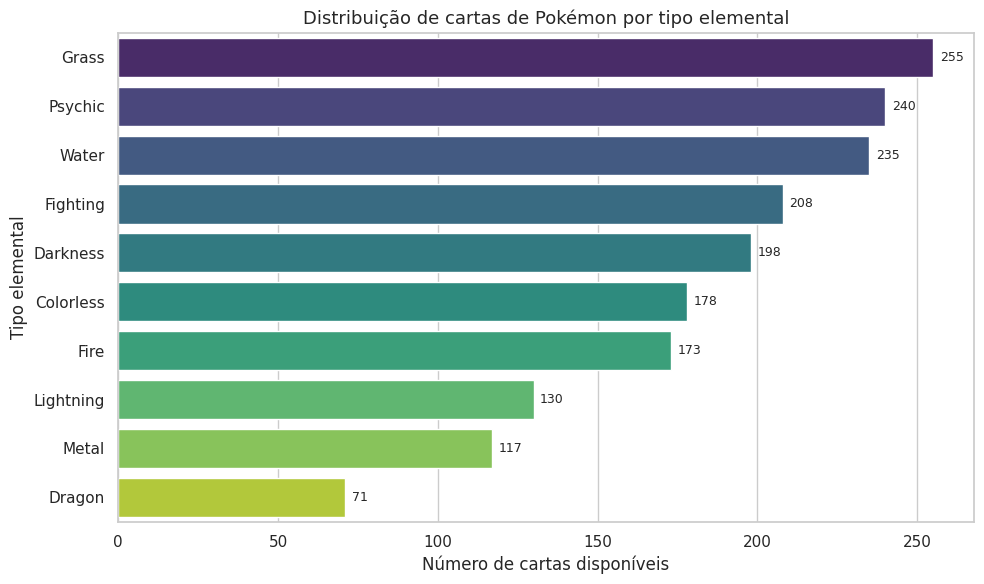

In [ ]:
type_counts = pokemon_df['Type_Clean'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=type_counts.values, y=type_counts.index, hue=type_counts.index,
            palette='viridis', legend=False, ax=ax)
ax.set_title('Distribuição de cartas de Pokémon por tipo elemental', fontsize=13)
ax.set_xlabel('Número de cartas disponíveis')
ax.set_ylabel('Tipo elemental')
for i, v in enumerate(type_counts.values):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** tipos como Grass, Psychic e Water têm a maior quantidade de cartas — ou seja, mais opções de montagem de baralho e maior probabilidade de encontrar sinergias fortes dentro do mesmo tipo. Dragon e Metal têm o menor número de opções, o que pode limitar a consistência de um baralho mono-tipo nessas categorias.


## Passo 5 — Extraindo custo de energia e dano dos ataques

As colunas `Cost` e `Damage` vêm em formato de texto não padronizado: o custo usa símbolos como `{F}{F}●` (dois de energia Fighting + uma energia incolor) e o dano pode ter modificadores como `30×` (dano variável, multiplicado por alguma condição do jogo).

Para analisar eficiência de ataque numericamente, precisamos extrair valores numéricos limpos dessas strings.

**Camada técnica:**
- Usamos **expressões regulares** (`re`) para:
  - Contar quantos símbolos de energia `{X}` ou `●` aparecem em `Cost` → custo total de energia do ataque.
  - Extrair o número inicial de `Damage`, ignorando sufixos como `×` → dano base do ataque.
- `.apply()` aplica essas funções linha a linha na coluna.
- Calculamos `Eficiencia = Dano_Base / Custo_Energia`, uma métrica de "dano por energia investida" — quanto maior, mais "barato" é o ataque em relação ao poder de fogo.

**Camada leiga:**
Imagine que cada ataque tem um "preço" (quanta energia você precisa anexar ao Pokémon) e um "retorno" (quanto de dano ele causa). Dividir um pelo outro nos dá uma métrica simples: ataques com alta eficiência dão muito dano por pouco investimento — são geralmente os mais competitivos.


In [ ]:
def contar_custo_energia(cost_str):
    """Conta o total de simbolos de energia exigidos por um ataque (tipados + incolor)."""
    if pd.isna(cost_str):
        return np.nan
    chaves = re.findall(r'\{[^}]+\}', cost_str)   # encontra todos os {X}
    incolor = cost_str.count('●')                  # cada • é 1 energia incolor
    return len(chaves) + incolor

def extrair_dano_base(damage_str):
    """Extrai o numero inicial do dano, ignorando modificadores como x ou +."""
    if pd.isna(damage_str):
        return np.nan
    match = re.match(r'(\d+)', str(damage_str))
    return int(match.group(1)) if match else np.nan

pokemon_df['Custo_Energia'] = pokemon_df['Cost'].apply(contar_custo_energia)
pokemon_df['Dano_Base'] = pokemon_df['Damage'].apply(extrair_dano_base)

# Eficiência = dano por ponto de energia investido (evita divisão por zero)
pokemon_df['Eficiencia'] = pokemon_df['Dano_Base'] / pokemon_df['Custo_Energia'].replace(0, np.nan)

# Top 10 ataques mais eficientes do ambiente competitivo
top_eficientes = pokemon_df[['Card Name', 'Type_Clean', 'Cost', 'Custo_Energia',
                              'Damage', 'Dano_Base', 'Eficiencia']]\
    .dropna(subset=['Eficiencia'])\
    .sort_values('Eficiencia', ascending=False)\
    .head(10)

top_eficientes

,Card Name,Type_Clean,Cost,Custo_Energia,Damage,Dano_Base,Eficiencia
184,Palafin ex,Water,{W},1.0,250,250.0,250.0
1372,Ceruledge,Fire,{R},1.0,220,220.0,220.0
57,Greninja ex,Fighting,{W},1.0,170,170.0,170.0
229,Decidueye,Grass,{G},1.0,170,170.0,170.0
1513,Medicham,Fighting,{F},1.0,150,150.0,150.0
1819,Diggersby,Colorless,●,1.0,140,140.0,140.0
428,Slaking ex,Colorless,●●,2.0,280,280.0,140.0
1184,Mega Lucario ex,Fighting,{F}{F},2.0,270,270.0,135.0
77,Palafin,Water,{W},1.0,130,130.0,130.0
1183,Mega Lucario ex,Fighting,{F},1.0,130,130.0,130.0


**Leitura da tabela:** cartas como *Palafin ex* e *Ceruledge* aparecem no topo por entregarem dano altíssimo (250 e 220, respectivamente) por apenas 1 energia — embora, no jogo real, esse tipo de ataque costume vir com uma condição especial (ex: precisar trocar de Pokémon Ativo antes). Isso é um ponto importante para o relatório: **eficiência bruta nem sempre conta a história completa**, então no relatório final vale complementar com a leitura da coluna `Effect Explanation`.


## Passo 6 — Eficiência de ataque por tipo elemental

Agora cruzamos a métrica de eficiência com o tipo elemental: **quais tipos, em média, têm os ataques mais eficientes?**

**Camada técnica:**
- `.groupby('Type_Clean')` agrupa todas as cartas pelo tipo elemental.
- `sns.boxplot()` mostra a distribuição completa (mediana, quartis, outliers) de eficiência por grupo — mais informativo que uma simples média, pois revela a variabilidade dentro de cada tipo.

**Camada leiga:**
Um boxplot é como um "resumo visual" da variação dentro de cada grupo: a linha do meio é o valor mais típico, a caixa mostra onde está a maioria das cartas, e os pontos isolados são exceções (cartas muito acima ou abaixo do padrão do seu tipo).


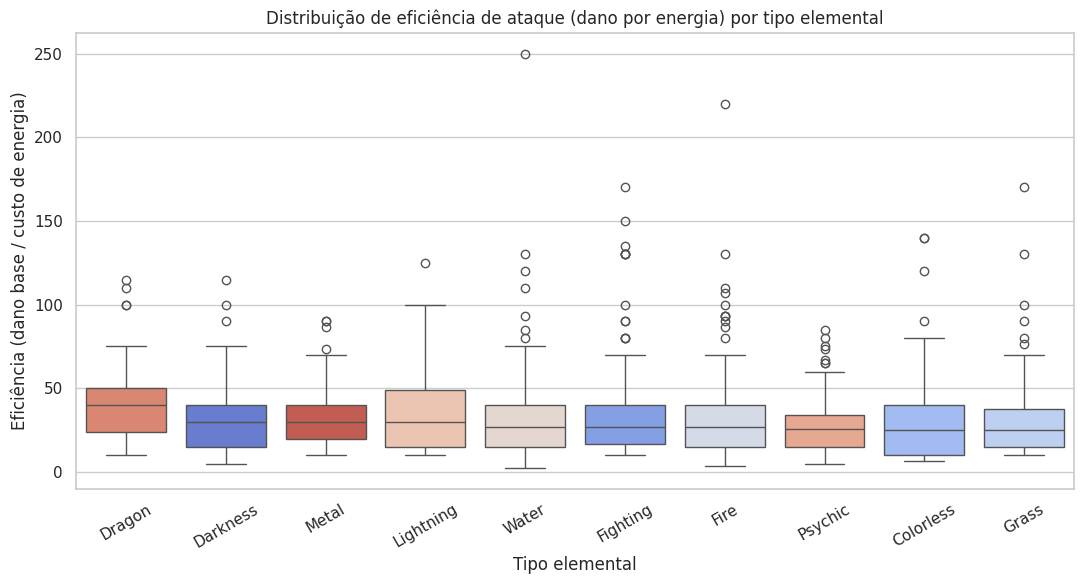

In [ ]:
# Filtra apenas linhas com eficiência calculável, para não distorcer o gráfico
plot_df = pokemon_df.dropna(subset=['Eficiencia', 'Type_Clean'])
plot_df = plot_df[plot_df['Type_Clean'] != 'Special/Other']

ordem_tipos = plot_df.groupby('Type_Clean')['Eficiencia'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=plot_df, x='Type_Clean', y='Eficiencia', order=ordem_tipos,
            hue='Type_Clean', palette='coolwarm', legend=False, ax=ax)
ax.set_title('Distribuição de eficiência de ataque (dano por energia) por tipo elemental')
ax.set_xlabel('Tipo elemental')
ax.set_ylabel('Eficiência (dano base / custo de energia)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** tipos com mediana de eficiência mais alta tendem a ter ataques que recompensam melhor o investimento de energia — um fator relevante para decidir a "linha de ataque" principal de um baralho, especialmente em um simulador de IA onde otimizar a curva de energia por turno é decisivo.


## Passo 7 — HP médio e custo de recuo por tipo

Dois outros fatores estratégicos centrais: **HP** (quanto dano o Pokémon resiste antes de ser derrotado) e **Retreat Cost** (quantas energias custa trocar o Pokémon Ativo pelo Banco). Baralhos competitivos costumam balancear ataque com resiliência.

**Camada técnica:**
- `.agg()` permite calcular múltiplas estatísticas (média, contagem) de uma vez, por grupo.
- Arredondamos com `.round(1)` para facilitar a leitura da tabela.

**Camada leiga:**
HP alto = o Pokémon "aguenta mais pancada" antes de cair. Custo de recuo baixo = é mais fácil tirá-lo da linha de frente quando ele está em perigo, sem gastar muitos turnos fazendo isso.


In [ ]:
resumo_tipo = pokemon_df.groupby('Type_Clean').agg(
    Qtd_Cartas=('Card Name', 'count'),
    HP_Medio=('HP', 'mean'),
    Recuo_Medio=('Retreat', 'mean'),
    Dano_Medio=('Dano_Base', 'mean'),
    Eficiencia_Media=('Eficiencia', 'mean')
).round(1).sort_values('Eficiencia_Media', ascending=False)

resumo_tipo

,Qtd_Cartas,HP_Medio,Recuo_Medio,Dano_Medio,Eficiencia_Media
Type_Clean,,,,,
Dragon,71,153.7,1.8,100.4,41.7
Fighting,208,134.1,2.1,71.0,35.3
Lightning,130,140.5,1.3,75.8,34.2
Fire,173,143.9,1.9,73.6,33.9
Metal,117,142.8,2.1,77.1,32.3
Water,235,130.7,1.8,65.3,31.3
Colorless,178,123.3,1.6,63.0,30.8
Grass,255,118.3,1.6,56.6,30.2
Darkness,198,139.6,1.8,66.1,30.1


## Passo 8 — Mapeando o "meta" de fraquezas elementais

Em PTCG, cada tipo costuma ter uma fraqueza elemental fixa (ex: Grass é fraco contra Fire). Entender esse padrão é essencial para prever **contra quais tipos seu baralho vai sofrer mais dano**, e também para escolher um tipo de ataque que explore bem as fraquezas dos adversários mais comuns.

**Camada técnica:**
- `pd.crosstab()` cria uma tabela de contingência cruzando duas colunas categóricas — aqui, Tipo do Pokémon × sua Fraqueza.
- `sns.heatmap()` colore essa tabela conforme a magnitude dos valores, facilitando a leitura visual de padrões.

**Camada leiga:**
É um "mapa de pontos fracos" do jogo: cada linha mostra um tipo de Pokémon, cada coluna mostra contra qual elemento ele é vulnerável, e a cor (e o número) mostram quantas cartas seguem aquele padrão. Quanto mais escura a célula, mais forte é aquele padrão no jogo.


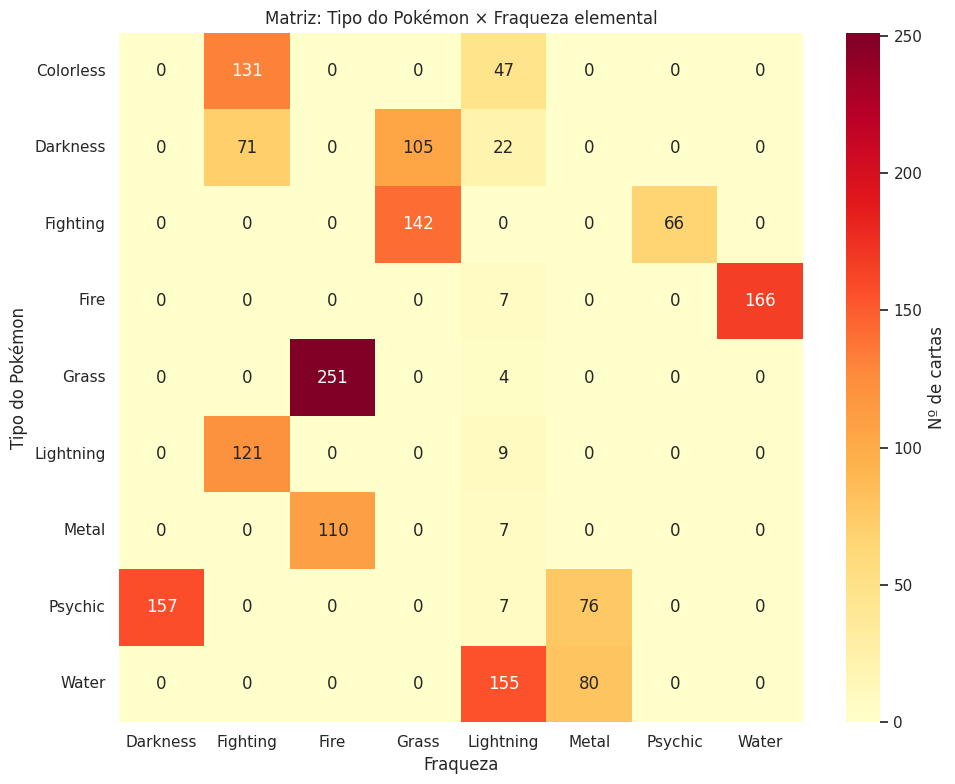

In [ ]:
matriz_fraqueza = pd.crosstab(pokemon_df['Type_Clean'], pokemon_df['Weakness_Clean'])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matriz_fraqueza, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Nº de cartas'})
ax.set_title('Matriz: Tipo do Pokémon × Fraqueza elemental')
ax.set_xlabel('Fraqueza')
ax.set_ylabel('Tipo do Pokémon')
plt.tight_layout()
plt.show()

**Leitura do mapa de calor:** o padrão é nítido — Grass é quase universalmente fraco contra Fire, Water é fraco contra Lightning, Fighting é fraco contra Psychic. Esse tipo de relação é **fixo na maior parte das cartas do jogo**, então é um dado confiável para fundamentar a escolha de um tipo de ataque que tenha boa cobertura contra os tipos mais populares do formato.


## Passo 9 — Cartas de Treinador: motores de consistência

Baralhos de PTCG dependem fortemente de cartas de Treinador (Supporter, Item, Stadium) para garantir consistência — puxar mais cartas, buscar Pokémon específicos no baralho, ou remover ameaças do oponente. Vamos identificar quais efeitos são mais comuns no ambiente.

**Camada técnica:**
- Usamos `.str.contains()` com palavras-chave (case-insensitive) na coluna `Effect Explanation` para classificar cartas por função: "draw" (compra), "search" (busca), "switch" (troca).
- Isso é uma forma simples de **categorização baseada em texto**, útil quando não há uma coluna estruturada para esse propósito.

**Camada leiga:**
Lemos a descrição de cada carta de Treinador procurando por palavras-chave que indicam sua função — se ela ajuda a "puxar mais cartas da mão", "buscar uma carta específica no baralho" ou "forçar o oponente a trocar de Pokémon". Isso nos dá um panorama de quantas ferramentas de consistência estão disponíveis no formato.


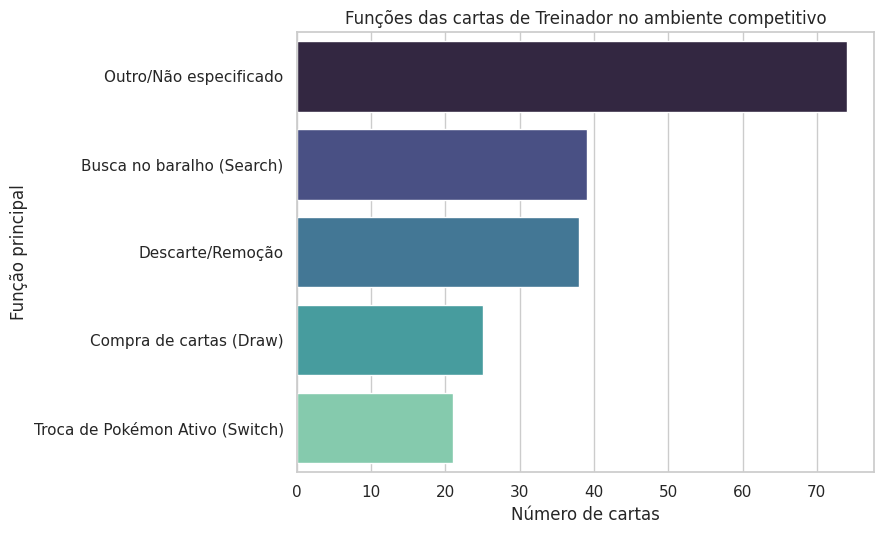

In [ ]:
def classificar_funcao(texto):
    if pd.isna(texto):
        return 'Outro/Não especificado'
    texto = texto.lower()
    if 'draw' in texto:
        return 'Compra de cartas (Draw)'
    elif 'search your deck' in texto:
        return 'Busca no baralho (Search)'
    elif 'switch' in texto or 'active spot' in texto:
        return 'Troca de Pokémon Ativo (Switch)'
    elif 'discard' in texto:
        return 'Descarte/Remoção'
    else:
        return 'Outro/Não especificado'

trainer_df['Funcao'] = trainer_df['Effect Explanation'].apply(classificar_funcao)

funcao_counts = trainer_df['Funcao'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=funcao_counts.values, y=funcao_counts.index, hue=funcao_counts.index,
            palette='mako', legend=False, ax=ax)
ax.set_title('Funções das cartas de Treinador no ambiente competitivo')
ax.set_xlabel('Número de cartas')
ax.set_ylabel('Função principal')
plt.tight_layout()
plt.show()

## Passo 10 — Síntese: recomendação de arquétipo fundamentada em dados

Juntando as análises anteriores, podemos justificar a escolha de um arquétipo de baralho com base em evidências, não apenas intuição:

1. **Variedade de cartas** (Passo 4): tipos com mais opções permitem maior flexibilidade de montagem e menor dependência de uma única carta rara.
2. **Eficiência de ataque** (Passos 5–6): indica quais tipos entregam mais dano por energia investida — relevante para otimizar o ritmo de jogo (quantos turnos até o "ataque decisivo").
3. **HP médio e custo de recuo** (Passo 7): equilíbrio entre resistência e mobilidade tática.
4. **Cobertura de fraquezas** (Passo 8): evita que o baralho dependa de "sorte de matchup" — um dos critérios explícitos de avaliação ("evita a dependência excessiva de... vantagens situacionais").
5. **Suporte de consistência** (Passo 9): mostra quantas ferramentas de Treinador existem no formato para apoiar qualquer arquétipo escolhido.

Vamos consolidar isso em uma tabela-resumo final, ordenando os tipos por uma pontuação combinada simples (normalizando e somando eficiência e HP, e penalizando recuo alto).


In [ ]:
# Normalização simples (0 a 1) das métricas relevantes para compor um score comparável
score_df = resumo_tipo.copy()

for col in ['HP_Medio', 'Eficiencia_Media']:
    score_df[col + '_norm'] = (score_df[col] - score_df[col].min()) / (score_df[col].max() - score_df[col].min())

# Recuo baixo é bom -> invertemos a normalização
score_df['Recuo_Medio_norm'] = 1 - (score_df['Recuo_Medio'] - score_df['Recuo_Medio'].min()) / (score_df['Recuo_Medio'].max() - score_df['Recuo_Medio'].min())

score_df['Score_Arquetipo'] = (
    score_df['HP_Medio_norm'] * 0.3 +
    score_df['Eficiencia_Media_norm'] * 0.5 +
    score_df['Recuo_Medio_norm'] * 0.2
).round(3)

score_df[['Qtd_Cartas', 'HP_Medio', 'Recuo_Medio', 'Eficiencia_Media', 'Score_Arquetipo']]\
    .sort_values('Score_Arquetipo', ascending=False)

,Qtd_Cartas,HP_Medio,Recuo_Medio,Eficiencia_Media,Score_Arquetipo
Type_Clean,,,,,
Dragon,71,153.7,1.8,41.7,0.875
Lightning,130,140.5,1.3,34.2,0.612
Fire,173,143.9,1.9,33.9,0.480
Fighting,208,134.1,2.1,35.3,0.399
Metal,117,142.8,2.1,32.3,0.362
Darkness,198,139.6,1.8,30.1,0.329
Water,235,130.7,1.8,31.3,0.298
Colorless,178,123.3,1.6,30.8,0.267
Grass,255,118.3,1.6,30.2,0.202


**Como usar esse score no relatório do Kaggle:** o `Score_Arquetipo` não é uma "verdade absoluta" — é um ponto de partida quantitativo que você deve complementar com leitura qualitativa das cartas específicas (efeitos de `Effect Explanation`, sinergias entre Pokémon e Treinadores, e o que de fato seu agente de IA consegue executar bem no simulador).

No relatório da Categoria Estratégia, o ideal é:
- Apresentar este ranking como evidência inicial.
- Escolher 1–2 tipos no topo do ranking e detalhar manualmente 15–20 cartas específicas que formariam o baralho (usando o `Card_ID_List_EN.pdf` como referência visual).
- Conectar a escolha com o desempenho observado do agente na Categoria Simulação (taxa de vitórias, partidas onde o matchup foi desfavorável, etc.) — isso é o que realmente sustenta os 70% de peso da "Pontuação do modelo".

---

### Próximos passos sugeridos
- Repetir esta análise com `JP_Card_Data.csv` para checar se há cartas exclusivas de uma versão.
- Cruzar os IDs de carta deste dataset com os logs de partida do seu agente (se a Categoria Simulação já estiver em andamento) para validar empiricamente se o tipo recomendado aqui de fato vence mais.
- Usar o PDF `Card_ID_List_EN.pdf` para conferir visualmente as cartas específicas escolhidas, já que ele contém a imagem de cada carta.
